##**TASK-1**

###Import statements

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

###Data Pre-processing

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
     'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df.drop('Name', axis=1, inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
title_map = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}
df['Title'] = df['Title'].map(title_map)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3785/1110624908.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


###Correlation Heat Map

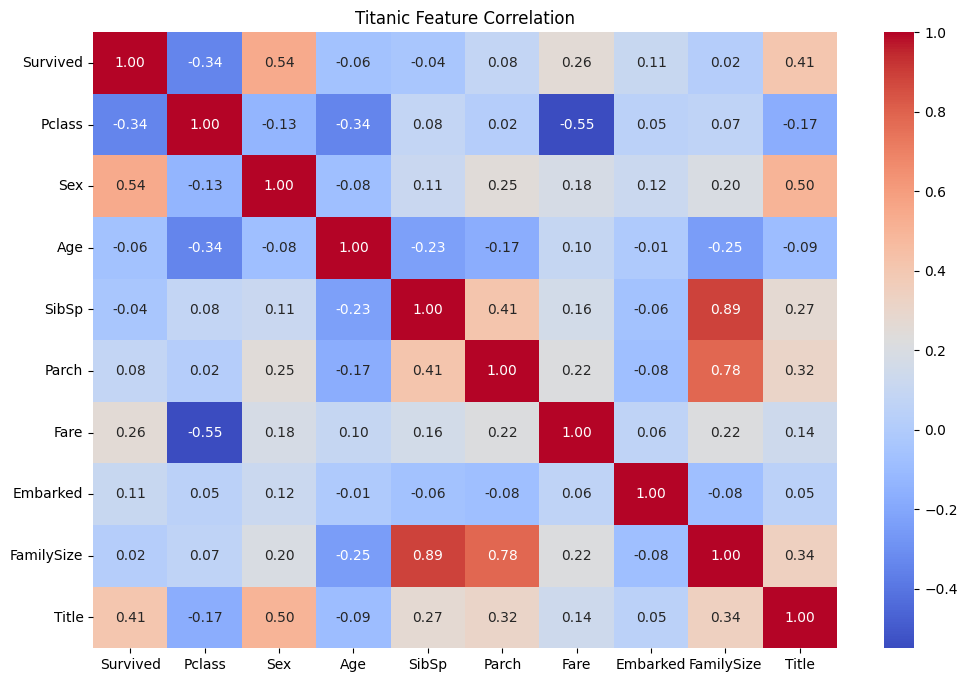

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Titanic Feature Correlation")
plt.show()

###Random forest model training and prediction

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

###Accuracy and classification report of the model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy: 82.68 %

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



###Confusion matrix

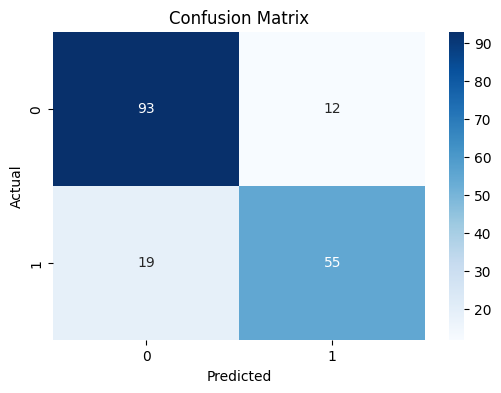

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###User Prediction

In [ ]:
print("\nEnter Passenger Details")
pclass = int(input("Passenger Class (1/2/3): "))
sex = input("Sex (male/female): ").lower()
age = float(input("Age: "))
sibsp = int(input("Siblings/Spouses Aboard: "))
parch = int(input("Parents/Children Aboard: "))
fare = float(input("Fare: "))
embarked = input("Embarked (S/C/Q): ").upper()
family_size = sibsp + parch + 1
sex_value = 0 if sex == "male" else 1
embarked_map = {
    'S': 0,
    'C': 1,
    'Q': 2
}
embarked_value = embarked_map[embarked]
if sex == "male":
    title = 1
else:
    title = 2
user_data = pd.DataFrame({
    'Pclass': [pclass],
    'Sex': [sex_value],
    'Age': [age],
    'SibSp': [sibsp],
    'Parch': [parch],
    'Fare': [fare],
    'Embarked': [embarked_value],
    'FamilySize': [family_size],
    'Title': [title]
})
prediction = rf.predict(user_data)
print("\nPrediction Result")
if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")


Enter Passenger Details
Passenger Class (1/2/3): 1
Sex (male/female): female
Age: 22
Siblings/Spouses Aboard: 1
Parents/Children Aboard: 0
Fare: 100
Embarked (S/C/Q): C

Prediction Result
Passenger Survived
